# Diffrax: Differential Equation Solvers in JAX

**Diffrax** is a JAX library for numerical differential equation solvers. It provides:

- ODEs (Ordinary Differential Equations)
- SDEs (Stochastic Differential Equations)
- CDEs (Controlled Differential Equations)

All solvers are **fully differentiable** and **JIT-compilable**.

## What You'll Learn

1. Basic ODE solving with diffrax
2. Available solvers (explicit, implicit, adaptive)
3. Stiff systems and implicit methods
4. Adjoint methods for gradients
5. SDEs and noise
6. Neural ODEs
7. Chemical engineering applications

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import diffrax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"Diffrax version: {diffrax.__version__}")

W0000 00:00:1767133638.362683 4089985 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767133638.372075 4089985 service.cc:145] XLA service 0x600000f18700 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767133638.372083 4089985 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767133638.373112 4089985 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767133638.373120 4089985 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


JAX version: 0.8.1
Diffrax version: 0.7.0


## 1. Basic ODE Solving

An ODE has the form: $\frac{dy}{dt} = f(t, y, \text{args})$

Diffrax solves this with:
1. **Term**: Defines the vector field $f$
2. **Solver**: The numerical method
3. **diffeqsolve**: The main solve function

In [2]:
# Example: Exponential decay dy/dt = -k*y
def exponential_decay(t, y, args):
    k = args
    return -k * y

# Define the ODE term
term = diffrax.ODETerm(exponential_decay)

# Choose a solver
solver = diffrax.Dopri5()  # Classic Runge-Kutta 4/5

# Solve
t0, t1 = 0.0, 5.0
y0 = jnp.array(1.0)
k = 0.5

solution = diffrax.diffeqsolve(
    term,
    solver,
    t0=t0,
    t1=t1,
    dt0=0.1,  # Initial step size
    y0=y0,
    args=k,
    saveat=diffrax.SaveAt(ts=jnp.linspace(t0, t1, 50))
)

print(f"Solution shape: {solution.ys.shape}")
print(f"Final value: {solution.ys[-1]:.6f}")
print(f"Exact: {jnp.exp(-k * t1):.6f}")

Solution shape: (50,)
Final value: 0.082085
Exact: 0.082085


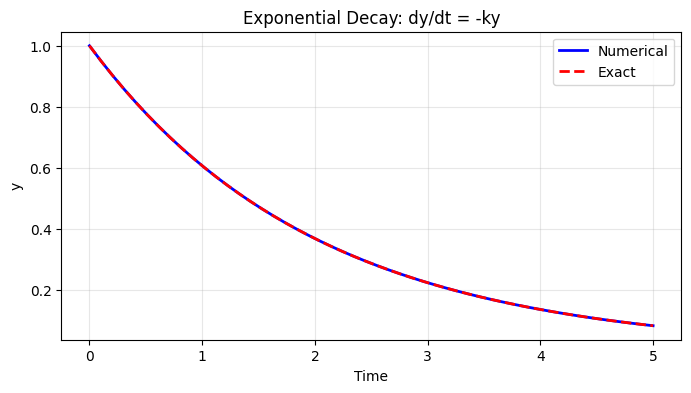

In [3]:
# Plot solution
plt.figure(figsize=(8, 4))
plt.plot(solution.ts, solution.ys, 'b-', label='Numerical', linewidth=2)
plt.plot(solution.ts, jnp.exp(-k * solution.ts), 'r--', label='Exact', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Exponential Decay: dy/dt = -ky')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Available Solvers

Diffrax provides many solvers for different problem types:

### Explicit Solvers (non-stiff problems)
| Solver | Order | Adaptive | Notes |
|--------|-------|----------|-------|
| `Euler` | 1 | No | Simplest, rarely used |
| `Heun` | 2 | No | Improved Euler |
| `Midpoint` | 2 | No | Second-order |
| `Ralston` | 2 | No | Optimal 2nd order |
| `Bosh3` | 3 | Yes | Bogacki-Shampine |
| `Tsit5` | 5 | Yes | Tsitouras 5/4 (recommended) |
| `Dopri5` | 5 | Yes | Dormand-Prince 5/4 |
| `Dopri8` | 8 | Yes | High accuracy |

### Implicit Solvers (stiff problems)
| Solver | Order | Notes |
|--------|-------|-------|
| `ImplicitEuler` | 1 | Basic implicit |
| `Kvaerno3` | 3 | Good for moderate stiffness |
| `Kvaerno4` | 4 | Balanced accuracy/stability |
| `Kvaerno5` | 5 | High-order implicit (recommended) |

In [4]:
# Compare solvers on Lotka-Volterra (predator-prey)
def lotka_volterra(t, y, args):
    """Predator-prey dynamics.
    
    y[0] = prey population
    y[1] = predator population
    """
    alpha, beta, gamma, delta = args
    prey, pred = y
    d_prey = alpha * prey - beta * prey * pred
    d_pred = delta * prey * pred - gamma * pred
    return jnp.array([d_prey, d_pred])

# Parameters
params = (1.0, 0.1, 0.5, 0.02)  # alpha, beta, gamma, delta
y0 = jnp.array([40.0, 9.0])     # Initial populations
t_span = (0.0, 50.0)
t_eval = jnp.linspace(0, 50, 500)

term = diffrax.ODETerm(lotka_volterra)

# Solve with different methods
solvers = {
    'Euler (dt=0.1)': (diffrax.Euler(), 0.1, None),
    'Tsit5 (adaptive)': (diffrax.Tsit5(), 0.1, diffrax.PIDController(rtol=1e-5, atol=1e-8)),
    'Dopri8 (adaptive)': (diffrax.Dopri8(), 0.1, diffrax.PIDController(rtol=1e-8, atol=1e-10)),
}

results = {}
for name, (solver, dt0, stepsize_controller) in solvers.items():
    sol = diffrax.diffeqsolve(
        term, solver,
        t0=t_span[0], t1=t_span[1],
        dt0=dt0,
        y0=y0,
        args=params,
        saveat=diffrax.SaveAt(ts=t_eval),
        stepsize_controller=stepsize_controller or diffrax.ConstantStepSize(),
        max_steps=100000
    )
    results[name] = sol

print("Solutions computed for all solvers")

Solutions computed for all solvers


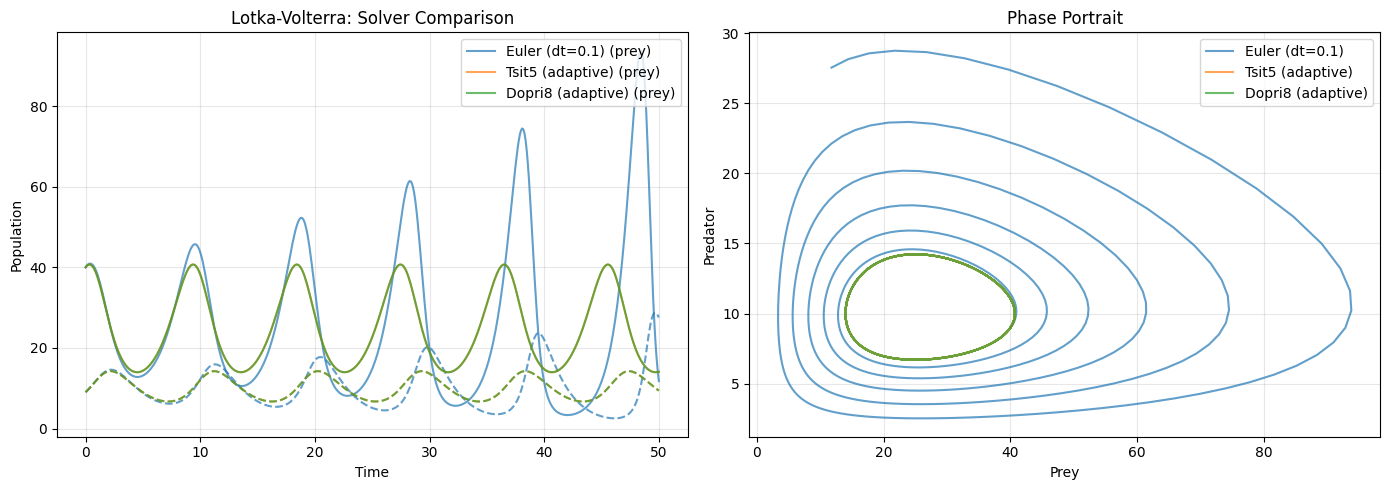

In [5]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
ax = axes[0]
colors = ['C0', 'C1', 'C2']
for i, (name, sol) in enumerate(results.items()):
    ax.plot(sol.ts, sol.ys[:, 0], color=colors[i], linestyle='-', 
            label=f'{name} (prey)', alpha=0.7)
    ax.plot(sol.ts, sol.ys[:, 1], color=colors[i], linestyle='--', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Lotka-Volterra: Solver Comparison')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Phase portrait
ax = axes[1]
for name, sol in results.items():
    ax.plot(sol.ys[:, 0], sol.ys[:, 1], label=name, alpha=0.7)
ax.set_xlabel('Prey')
ax.set_ylabel('Predator')
ax.set_title('Phase Portrait')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Note: Euler diverges while adaptive methods maintain the limit cycle!

## 3. Stiff Systems and Implicit Methods

**Stiff systems** have dynamics at very different time scales. Explicit methods require tiny time steps, making them impractical.

Example: Robertson's chemical kinetics problem (classic stiff test case)

In [6]:
def robertson(t, y, args):
    """Robertson's stiff chemical kinetics.
    
    A -> B    (slow:  k1 = 0.04)
    B + B -> C + B  (fast: k2 = 3e7)
    B + C -> A + C  (medium: k3 = 1e4)
    """
    k1, k2, k3 = 0.04, 3e7, 1e4
    A, B, C = y
    dA = -k1*A + k3*B*C
    dB = k1*A - k2*B*B - k3*B*C
    dC = k2*B*B
    return jnp.array([dA, dB, dC])

# Initial conditions: pure A
y0 = jnp.array([1.0, 0.0, 0.0])

# Time span (log scale to capture fast initial dynamics)
t_eval = jnp.logspace(-5, 6, 200)

term = diffrax.ODETerm(robertson)

In [7]:
# Solve with implicit method (Kvaerno5)
solver = diffrax.Kvaerno5()
stepsize_controller = diffrax.PIDController(rtol=1e-8, atol=1e-10)

solution = diffrax.diffeqsolve(
    term, solver,
    t0=1e-5, t1=1e6,
    dt0=1e-6,
    y0=y0,
    saveat=diffrax.SaveAt(ts=t_eval),
    stepsize_controller=stepsize_controller,
    max_steps=10000
)

print(f"Integration successful!")
print(f"Final concentrations: A={solution.ys[-1, 0]:.4f}, B={solution.ys[-1, 1]:.2e}, C={solution.ys[-1, 2]:.4f}")
print(f"Mass conservation check: {jnp.sum(solution.ys[-1]):.6f} (should be 1.0)")

Integration successful!
Final concentrations: A=0.0020, B=8.14e-09, C=0.9980
Mass conservation check: 1.000000 (should be 1.0)


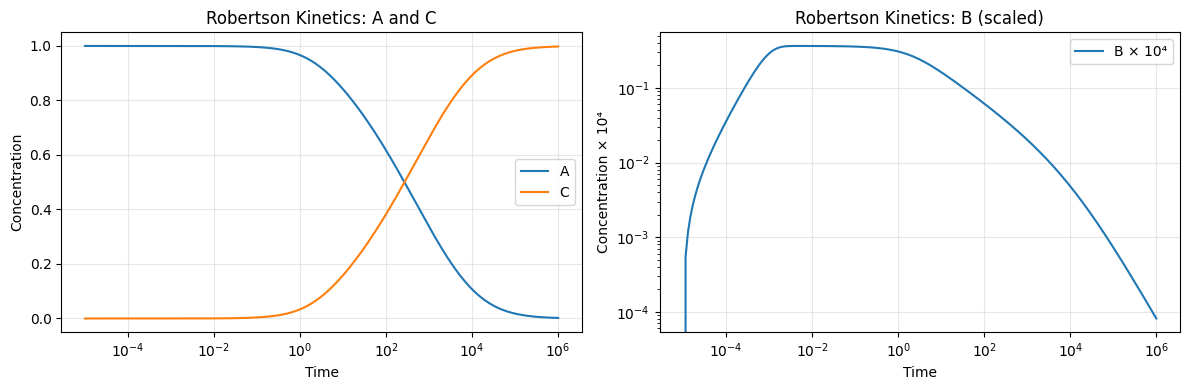

In [8]:
# Plot Robertson kinetics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogx(solution.ts, solution.ys[:, 0], label='A')
ax.semilogx(solution.ts, solution.ys[:, 2], label='C')
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Robertson Kinetics: A and C')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.loglog(solution.ts, solution.ys[:, 1] * 1e4, label='B × 10⁴')
ax.set_xlabel('Time')
ax.set_ylabel('Concentration × 10⁴')
ax.set_title('Robertson Kinetics: B (scaled)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Step Size Control

Diffrax provides several step size controllers:

| Controller | Description |
|------------|-------------|
| `ConstantStepSize()` | Fixed dt |
| `PIDController(rtol, atol)` | Adaptive PID control (recommended) |
| `StepTo(ts)` | Step exactly to specified times |

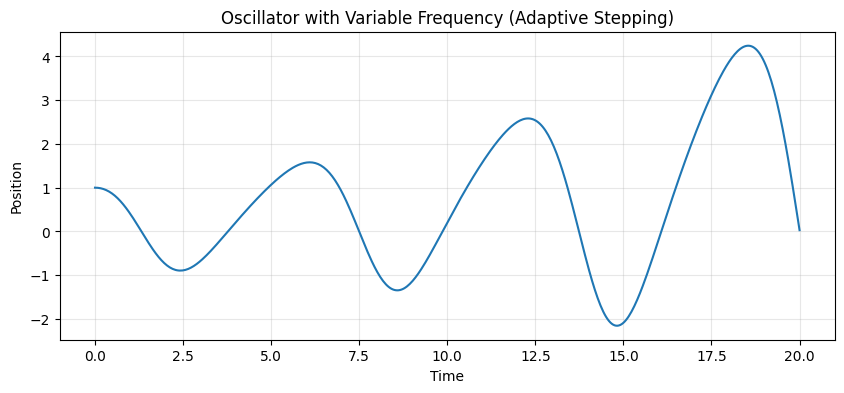

In [9]:
# Adaptive stepping example
def oscillator(t, y, args):
    """Simple harmonic oscillator with variable frequency."""
    omega = 1.0 + 0.5 * jnp.sin(t)  # Time-varying frequency
    return jnp.array([y[1], -omega**2 * y[0]])

y0 = jnp.array([1.0, 0.0])
term = diffrax.ODETerm(oscillator)

# Solve with adaptive stepping
solver = diffrax.Tsit5()
controller = diffrax.PIDController(
    rtol=1e-6,  # Relative tolerance
    atol=1e-9,  # Absolute tolerance
    pcoeff=0.0,  # P coefficient
    icoeff=1.0,  # I coefficient
    dcoeff=0.0   # D coefficient
)

t_eval = jnp.linspace(0, 20, 500)
solution = diffrax.diffeqsolve(
    term, solver,
    t0=0.0, t1=20.0,
    dt0=0.1,
    y0=y0,
    saveat=diffrax.SaveAt(ts=t_eval),
    stepsize_controller=controller
)

plt.figure(figsize=(10, 4))
plt.plot(solution.ts, solution.ys[:, 0])
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Oscillator with Variable Frequency (Adaptive Stepping)')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Computing Gradients Through ODEs

Diffrax supports **automatic differentiation through the ODE solve**. This is essential for:
- Parameter estimation
- Optimal control
- Neural ODEs

### Adjoint Methods

For efficiency with many parameters, use **adjoint methods**:

| Method | Memory | Best For |
|--------|--------|----------|
| `RecursiveCheckpointAdjoint` | O(log N) | Most problems (recommended) |
| `DirectAdjoint` | O(N) | Small problems, debugging |
| `BacksolveAdjoint` | O(1) | Reversible dynamics |

In [10]:
# Parameter estimation example: fit decay rate
def decay_ode(t, y, args):
    k = args
    return -k * y

# Generate synthetic data
true_k = 0.3
t_data = jnp.linspace(0, 5, 20)
y_data = jnp.exp(-true_k * t_data) + 0.02 * jax.random.normal(jax.random.PRNGKey(0), (20,))

def loss_fn(k):
    """Loss function: MSE between ODE solution and data."""
    term = diffrax.ODETerm(decay_ode)
    solver = diffrax.Tsit5()
    
    solution = diffrax.diffeqsolve(
        term, solver,
        t0=0.0, t1=5.0,
        dt0=0.1,
        y0=jnp.array(1.0),
        args=k,
        saveat=diffrax.SaveAt(ts=t_data),
        adjoint=diffrax.RecursiveCheckpointAdjoint()  # Memory-efficient gradients
    )
    
    return jnp.mean((solution.ys - y_data) ** 2)

# Compute gradient
k_init = 0.1
loss = loss_fn(k_init)
grad_k = grad(loss_fn)(k_init)

print(f"Initial k = {k_init}")
print(f"Loss = {loss:.6f}")
print(f"dL/dk = {grad_k:.6f}")

Initial k = 0.1
Loss = 0.081084
dL/dk = -1.137371


In [11]:
# Optimize k using gradient descent
import optax

k = jnp.array(0.1)
optimizer = optax.adam(0.05)
opt_state = optimizer.init(k)

losses = []
k_history = [float(k)]

for step in range(100):
    loss, grads = jax.value_and_grad(loss_fn)(k)
    updates, opt_state = optimizer.update(grads, opt_state, k)
    k = optax.apply_updates(k, updates)
    losses.append(float(loss))
    k_history.append(float(k))

print(f"\nFitted k = {float(k):.4f} (true: {true_k})")
print(f"Final loss = {losses[-1]:.6f}")


Fitted k = 0.2957 (true: 0.3)
Final loss = 0.000361


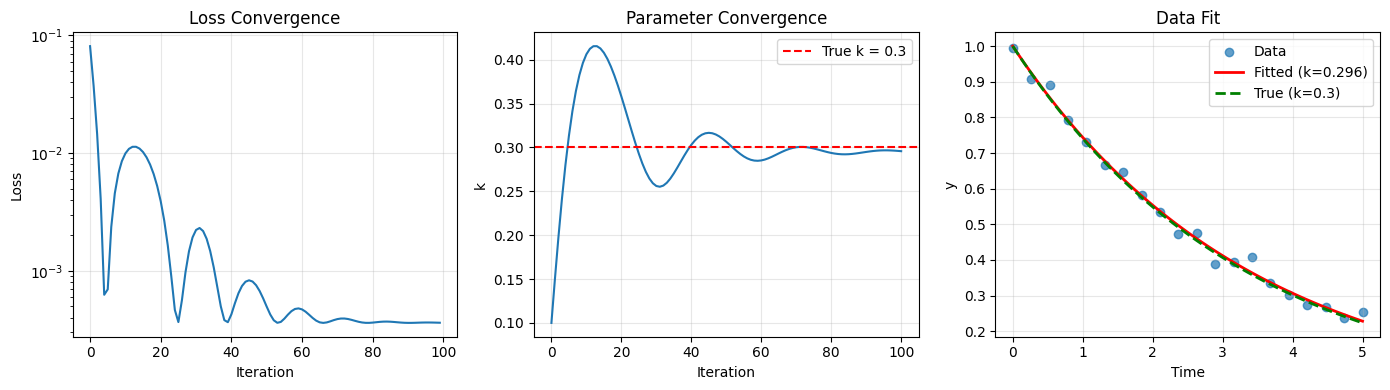

In [12]:
# Plot fitting results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss convergence
ax = axes[0]
ax.semilogy(losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Convergence')
ax.grid(True, alpha=0.3)

# k convergence
ax = axes[1]
ax.plot(k_history)
ax.axhline(true_k, color='r', linestyle='--', label=f'True k = {true_k}')
ax.set_xlabel('Iteration')
ax.set_ylabel('k')
ax.set_title('Parameter Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Data fit
ax = axes[2]
ax.scatter(t_data, y_data, label='Data', alpha=0.7)
t_fine = jnp.linspace(0, 5, 100)
ax.plot(t_fine, jnp.exp(-float(k) * t_fine), 'r-', label=f'Fitted (k={float(k):.3f})', linewidth=2)
ax.plot(t_fine, jnp.exp(-true_k * t_fine), 'g--', label=f'True (k={true_k})', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('y')
ax.set_title('Data Fit')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Chemical Engineering: Batch Reactor Optimization

Optimize the temperature profile of a batch reactor to maximize yield.

In [13]:
def batch_reactor(t, y, args):
    """Consecutive reactions: A -> B -> C
    
    We want to maximize B at t_final.
    Temperature affects rate constants via Arrhenius.
    """
    T_profile = args  # Temperature as function of time (neural network)
    
    # Get temperature at current time (interpolate or evaluate NN)
    T = T_profile(t)
    
    # Arrhenius rate constants
    R = 8.314
    k1 = 1e6 * jnp.exp(-50000 / (R * T))  # A -> B
    k2 = 1e8 * jnp.exp(-70000 / (R * T))  # B -> C
    
    A, B, C = y
    dA = -k1 * A
    dB = k1 * A - k2 * B
    dC = k2 * B
    
    return jnp.array([dA, dB, dC])

# Simple temperature profile: linear ramp
def make_T_profile(T_start, T_end, t_final):
    def T_profile(t):
        return T_start + (T_end - T_start) * t / t_final
    return T_profile

# Test with isothermal at different temperatures
y0 = jnp.array([1.0, 0.0, 0.0])
t_final = 100.0

def simulate(T_const):
    T_profile = lambda t: T_const
    term = diffrax.ODETerm(batch_reactor)
    solution = diffrax.diffeqsolve(
        term, diffrax.Tsit5(),
        t0=0.0, t1=t_final,
        dt0=0.1,
        y0=y0,
        args=T_profile,
        saveat=diffrax.SaveAt(ts=jnp.linspace(0, t_final, 200))
    )
    return solution

# Compare temperatures
temperatures = [350, 400, 450, 500]
results = {T: simulate(float(T)) for T in temperatures}

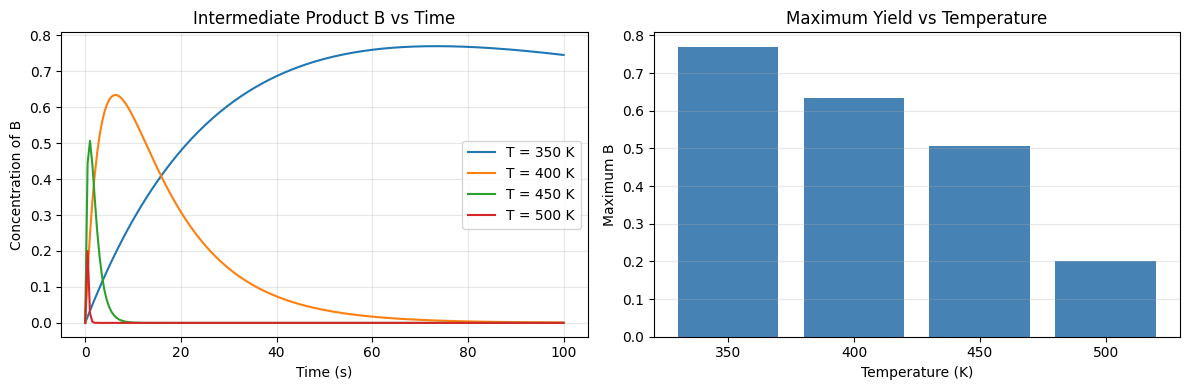


Optimal isothermal temperature: 400 K
But a time-varying profile could do even better!


In [14]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for T, sol in results.items():
    ax.plot(sol.ts, sol.ys[:, 1], label=f'T = {T} K')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration of B')
ax.set_title('Intermediate Product B vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
max_B = [float(jnp.max(sol.ys[:, 1])) for sol in results.values()]
ax.bar([str(T) for T in temperatures], max_B, color='steelblue')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Maximum B')
ax.set_title('Maximum Yield vs Temperature')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nOptimal isothermal temperature: 400 K")
print("But a time-varying profile could do even better!")

## 7. Neural ODEs

**Neural ODEs** parameterize the vector field with a neural network:

$$\frac{dy}{dt} = f_\theta(t, y)$$

where $f_\theta$ is a neural network with parameters $\theta$.

Libraries like **Equinox** integrate beautifully with diffrax.

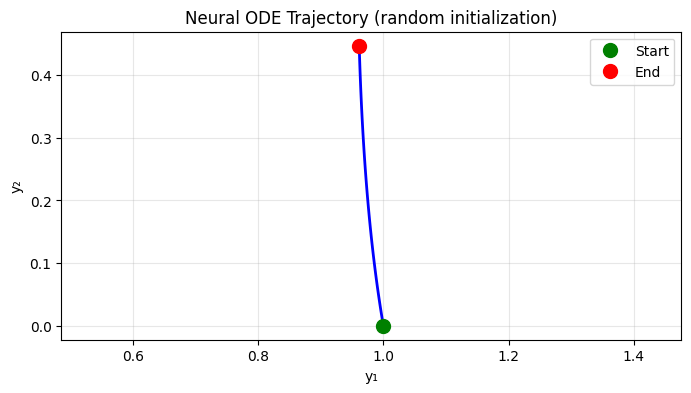

In [15]:
# Simple Neural ODE example (without Equinox for simplicity)
def mlp(params, y):
    """Simple MLP: y -> hidden -> output."""
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    h = jnp.tanh(y @ W1 + b1)
    return h @ W2 + b2

def neural_ode(t, y, params):
    """Neural network defines the dynamics."""
    return mlp(params, y)

# Initialize neural network
key = jax.random.PRNGKey(0)
keys = jax.random.split(key, 4)
hidden_dim = 16
state_dim = 2

params = {
    'W1': 0.1 * jax.random.normal(keys[0], (state_dim, hidden_dim)),
    'b1': jnp.zeros(hidden_dim),
    'W2': 0.1 * jax.random.normal(keys[2], (hidden_dim, state_dim)),
    'b2': jnp.zeros(state_dim)
}

# Forward pass
y0 = jnp.array([1.0, 0.0])
term = diffrax.ODETerm(neural_ode)

solution = diffrax.diffeqsolve(
    term, diffrax.Tsit5(),
    t0=0.0, t1=10.0,
    dt0=0.1,
    y0=y0,
    args=params,
    saveat=diffrax.SaveAt(ts=jnp.linspace(0, 10, 100)),
    adjoint=diffrax.RecursiveCheckpointAdjoint()
)

plt.figure(figsize=(8, 4))
plt.plot(solution.ys[:, 0], solution.ys[:, 1], 'b-', linewidth=2)
plt.plot(solution.ys[0, 0], solution.ys[0, 1], 'go', markersize=10, label='Start')
plt.plot(solution.ys[-1, 0], solution.ys[-1, 1], 'ro', markersize=10, label='End')
plt.xlabel('y₁')
plt.ylabel('y₂')
plt.title('Neural ODE Trajectory (random initialization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [16]:
# Train Neural ODE to fit spiral data
# Generate target spiral trajectory
t_target = jnp.linspace(0, 4*jnp.pi, 100)
spiral = jnp.stack([
    t_target * jnp.cos(t_target) / (4*jnp.pi),
    t_target * jnp.sin(t_target) / (4*jnp.pi)
], axis=1)

def loss_fn(params):
    """Match Neural ODE trajectory to spiral."""
    term = diffrax.ODETerm(neural_ode)
    solution = diffrax.diffeqsolve(
        term, diffrax.Tsit5(),
        t0=0.0, t1=4*jnp.pi,
        dt0=0.1,
        y0=jnp.array([0.0, 0.0]),
        args=params,
        saveat=diffrax.SaveAt(ts=t_target),
        adjoint=diffrax.RecursiveCheckpointAdjoint()
    )
    return jnp.mean((solution.ys - spiral) ** 2)

# Train
optimizer = optax.adam(0.01)
opt_state = optimizer.init(params)

losses = []
for step in range(500):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    losses.append(float(loss))
    
    if step % 100 == 0:
        print(f"Step {step}: loss = {loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

Step 0: loss = 0.167508


Step 100: loss = 0.142834


Step 200: loss = 0.163330


Step 300: loss = 0.155644


Step 400: loss = 0.142497



Final loss: 0.156829


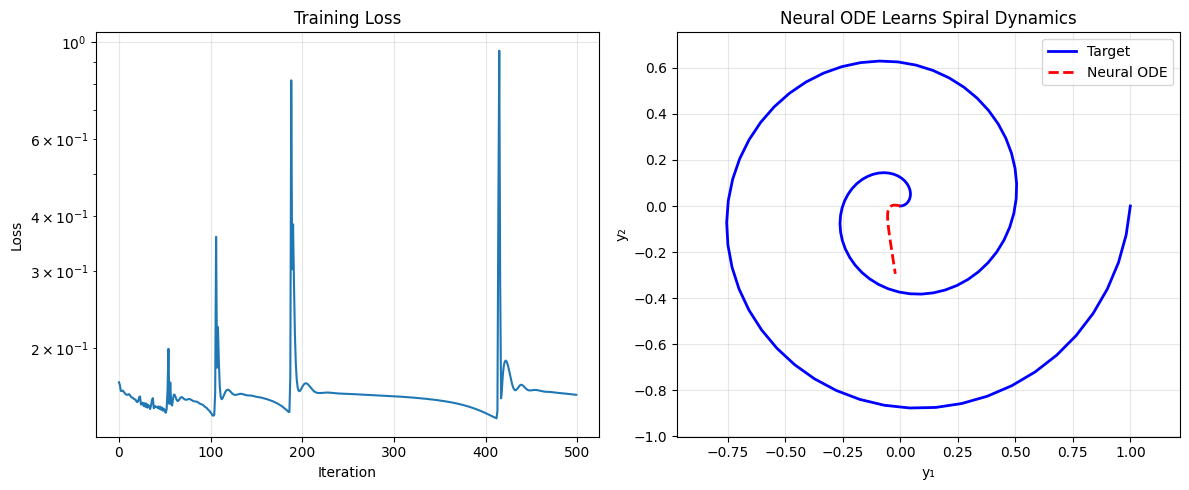

In [17]:
# Plot trained Neural ODE
term = diffrax.ODETerm(neural_ode)
trained_sol = diffrax.diffeqsolve(
    term, diffrax.Tsit5(),
    t0=0.0, t1=4*jnp.pi,
    dt0=0.1,
    y0=jnp.array([0.0, 0.0]),
    args=params,
    saveat=diffrax.SaveAt(ts=t_target)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.semilogy(losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spiral[:, 0], spiral[:, 1], 'b-', linewidth=2, label='Target')
ax.plot(trained_sol.ys[:, 0], trained_sol.ys[:, 1], 'r--', linewidth=2, label='Neural ODE')
ax.set_xlabel('y₁')
ax.set_ylabel('y₂')
ax.set_title('Neural ODE Learns Spiral Dynamics')
ax.legend()
ax.axis('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary

### Key diffrax Functions

| Function | Purpose |
|----------|----------|
| `ODETerm(f)` | Define ODE vector field |
| `diffeqsolve(...)` | Solve the differential equation |
| `SaveAt(ts=...)` | Specify output times |
| `PIDController(rtol, atol)` | Adaptive stepping |
| `RecursiveCheckpointAdjoint()` | Memory-efficient gradients |

### Solver Selection Guide

| Problem Type | Recommended Solver |
|--------------|--------------------|
| General ODE | `Tsit5()` |
| High accuracy | `Dopri8()` |
| Stiff systems | `Kvaerno5()` |
| Very stiff | `Kvaerno5()` with tight tolerances |

### Related Libraries

- **Equinox**: Neural network library that integrates with diffrax
- **Optimistix**: Nonlinear solvers (next tutorial)
- **Lineax**: Linear solvers for implicit methods

### Resources

- Documentation: https://docs.kidger.site/diffrax/
- GitHub: https://github.com/patrick-kidger/diffrax
- Neural ODE paper: Chen et al. "Neural Ordinary Differential Equations" (NeurIPS 2018)